# Comparative Analysis: Forward vs Reverse Prediction

## Setup and Implementations

In [26]:
import os
os.makedirs('plot', exist_ok=True)
import torch
from torch import nn
from torch.nn import functional as F
import math
import re
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pad_token = "[PAD]"
eos_token = "[EOS]"

class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "=", "c", "b"] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        out = re.sub(self.pattern, "", text)
        return out

    def pre_tokenization(self, text):
        return [c for c in text]

    def encode(self, text):
        text_list = self.pre_tokenization(self.clean(text))        
        return [self.token_to_id[c] for c in text_list]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=True,
            is_causal=is_causal
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src):        
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask, is_causal=True) 
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

def generate(model, prompts, new_tokens=5, device='cuda'):
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        last_output = output[-1, :, :]
        token = torch.argmax(last_output, -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor

## Data Generation Demonstration

To properly train the reverse model, the data generation process must be carefully designed to address several arithmetic challenges:

1. **Balancing Samples:** By default, random sampling leans heavily towards positive results. We strictly enforce a 50/50 split between positive and negative outcomes to prevent the model from learning statistical biases.
2. **Reverse Logic & Signs:** For negative results, predicting the string purely backwards (e.g., `-53` as `35-`) forces the model to compute complex modular arithmetic without knowing the final sign. We format our targets so the `-` sign is generated *first*, followed by the right-to-left digit math (e.g., `-53` is generated as `-` then `3` then `5`).
3. **Scratchpad for Carries and Borrows:** To alleviate the burden on the model's hidden states, we explicitly output carry (`c1`) and borrow (`b1`) states in the reverse sequence, turning the complex O(N) calculation into a series of O(1) steps.

Let's demonstrate this with the `sample_datapoint` function from our `src.utils`.

In [27]:
from src.utils import sample_datapoint

print("=== Positive Example (Addition with Carries) ===")
prompt, ans_fwd, ans_rev = sample_datapoint(3, force_negative=False)
print(f"Prompt:          {prompt}")
print(f"Forward Target:  {ans_fwd}")
print(f"Reverse Target:  {ans_rev}")
print("\nNotice the 'c1' tokens representing explicit carries.")

print("\n=== Negative Example (Subtraction with Borrows) ===")
prompt, ans_fwd, ans_rev = sample_datapoint(3, force_negative=True)
print(f"Prompt:          {prompt}")
print(f"Forward Target:  {ans_fwd}")
print(f"Reverse Target:  {ans_rev}")
print("\nNotice the '-' is placed first, and 'b1' tokens represent explicit borrows.")


=== Positive Example (Addition with Carries) ===
Prompt:          965-938=
Forward Target:  27
Reverse Target:  7b12

Notice the 'c1' tokens representing explicit carries.

=== Negative Example (Subtraction with Borrows) ===
Prompt:          367-884=
Forward Target:  -517
Reverse Target:  -7b115

Notice the '-' is placed first, and 'b1' tokens represent explicit borrows.


Next, we load the dataset and initialize both the Forward and Reverse models using the weights newly trained for 100 epochs.

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = character_level_tokenizer()

with open("assets/dataset.pkl", "rb") as f:
    dataset = pickle.load(f)
data_test = dataset["test"]
print(f"Test Set Loaded with {len(data_test)} examples")

model_fw = TransformerModel(ntoken=tokenizer.ntokens, ninp=128, nhead=16, nhid=64, nlayers=6).to(device)
model_fw.load_state_dict(torch.load("assets/forward_model.pth", map_location=device))
print("Forward Model Loaded Successfully")

model_rev = TransformerModel(ntoken=tokenizer.ntokens, ninp=128, nhead=16, nhid=64, nlayers=6).to(device)
model_rev.load_state_dict(torch.load("assets/reverse_model.pth", map_location=device))
print("Reverse Model Loaded Successfully")

Test Set Loaded with 20000 examples
Forward Model Loaded Successfully
Reverse Model Loaded Successfully


/tmp/ipykernel_5368/3013589081.py:82: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## Evaluation Functions

In [29]:
def evaluate_test(model, data, tokenizer, batch_size, device, mode="forward"):
    model.eval()
    results = []
    with torch.no_grad():
        for i in range(0, len(data), batch_size): 
            batch = data[i:i+batch_size]
            prompts = [tokenizer.encode(p) for p, a, a_rev in batch]
            max_prompt_len = max(len(p) for p in prompts)
            
            padded_prompts = [[tokenizer.token_to_id['[PAD]']] * (max_prompt_len - len(p)) + p for p in prompts]
            X = torch.tensor(padded_prompts, dtype=torch.long).transpose(0, 1).to(device)
            
            input_tensor = X
            for _ in range(15):
                output, _, _ = model(input_tensor)
                token = torch.argmax(output[-1, :, :], -1).view(1, -1)
                input_tensor = torch.cat((input_tensor, token), 0)
                
            pred_answers = input_tensor[max_prompt_len:, :]
            pred_answers = pred_answers.transpose(0, 1).cpu().tolist() 
            
            for b_idx, (p, a_fw, a_rev) in enumerate(batch):
                pred_tokens = pred_answers[b_idx]
                if tokenizer.token_to_id['[EOS]'] in pred_tokens:
                    eos_idx = pred_tokens.index(tokenizer.token_to_id['[EOS]'])
                    pred_tokens = pred_tokens[:eos_idx]
                
                pred_str = tokenizer.decode(pred_tokens)
                raw_pred = pred_str
                ans_str = a_fw if mode == 'forward' else a_rev
                
                op = "+" if "+" in p else "-"
                
                # Check for crossing zero (e.g., negative answers in subtraction)
                crossing_zero = (op == "-" and "-" in a_fw)
                
                # Check for asymmetric lengths (e.g. 100 - 9)
                ops_parts = p.replace("=","").split(op)
                asymmetric = len(ops_parts[0]) != len(ops_parts[1])
                
                results.append({
                    "prompt": p,
                    "true_ans": ans_str,
                    "pred_ans": pred_str,
                    "raw_pred": raw_pred,
                    "op": op,
                    "crossing_zero": crossing_zero,
                    "asymmetric": asymmetric,
                    "correct": pred_str == ans_str
                })
    return results

def compute_digit_accuracy(results, is_reverse=False):
    from collections import defaultdict
    pos_correct = defaultdict(int)
    pos_total = defaultdict(int)
    
    for r in results:
        t = r["true_ans"]
        p = r["pred_ans"]
        
        if is_reverse:
            # Clean intermediate steps and reverse back to standard forward format
            t = t.replace("c1", "").replace("b1", "").replace("c", "").replace("b", "")[::-1]
            p = p.replace("c1", "").replace("b1", "").replace("c", "").replace("b", "")[::-1]
            
        # Pad strings to the same length with leading spaces to align digits correctly
        max_len = max(len(t), len(p))
        t = t.rjust(max_len)
        p = p.rjust(max_len)
        
        # Now t and p are standard numbers (e.g. " 123" and " 123")
        # Reverse them so index 0 is units, index 1 is tens, etc.
        t_rev = t[::-1]
        p_rev = p[::-1]
        
        for i in range(len(t_rev)):
            if t_rev[i].strip() == "": continue # Skip padding
            pos_total[i] += 1
            if i < len(p_rev) and t_rev[i] == p_rev[i]:
                pos_correct[i] += 1
                
    accs = []
    for i in range(max(pos_total.keys()) + 1 if pos_total else 0):
        if pos_total[i] > 0:
            accs.append(pos_correct[i] / pos_total[i])
        else:
            accs.append(0)
    return accs

## Evaluation Loop

Evaluating the fully trained models to observe their performance.

In [30]:
batch_size = 500

print("Evaluating Forward Model (Trained for 100 Epochs)...")
res_fw = evaluate_test(model_fw, data_test, tokenizer, batch_size, device, mode="forward")

print("Evaluating Reverse Model (Trained for 100 Epochs)...")
res_rev = evaluate_test(model_rev, data_test, tokenizer, batch_size, device, mode="reverse")

fw_overall = sum([1 for r in res_fw if r["correct"]]) / len(res_fw)
rev_overall = sum([1 for r in res_rev if r["correct"]]) / len(res_rev)
print(f"\nOverall Accuracy - Forward: {fw_overall*100:.2f}%, Reverse: {rev_overall*100:.2f}%")


Evaluating Forward Model (Trained for 100 Epochs)...
Evaluating Reverse Model (Trained for 100 Epochs)...

Overall Accuracy - Forward: 98.42%, Reverse: 99.83%


## Operation Robustness

Comparing how well each model handles Addition vs. Subtraction.

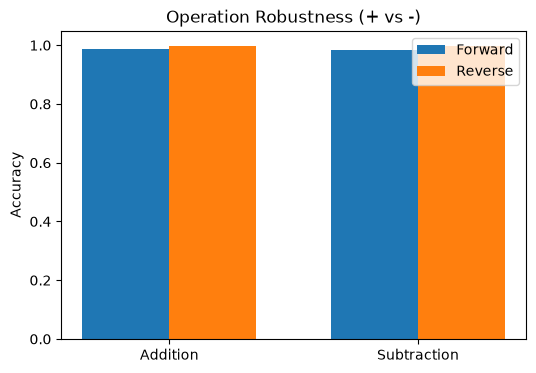

In [31]:
fw_add_acc = sum([1 for r in res_fw if r["op"] == "+" and r["correct"]]) / sum([1 for r in res_fw if r["op"] == "+"])
fw_sub_acc = sum([1 for r in res_fw if r["op"] == "-" and r["correct"]]) / sum([1 for r in res_fw if r["op"] == "-"])

rev_add_acc = sum([1 for r in res_rev if r["op"] == "+" and r["correct"]]) / max(1, sum([1 for r in res_rev if r["op"] == "+"]))
rev_sub_acc = sum([1 for r in res_rev if r["op"] == "-" and r["correct"]]) / max(1, sum([1 for r in res_rev if r["op"] == "-"]))

labels = ['Addition', 'Subtraction']
fw_accs = [fw_add_acc, fw_sub_acc]
rev_accs = [rev_add_acc, rev_sub_acc]

x = [0, 1]
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))
ax.bar([i - width/2 for i in x], fw_accs, width, label='Forward')
ax.bar([i + width/2 for i in x], rev_accs, width, label='Reverse')
ax.set_ylabel('Accuracy')
ax.set_title('Operation Robustness (+ vs -)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.savefig('plot/operation_robustness.png')
plt.show()

## Digit-level Performance

Comparing the positional accuracy of generated digits.

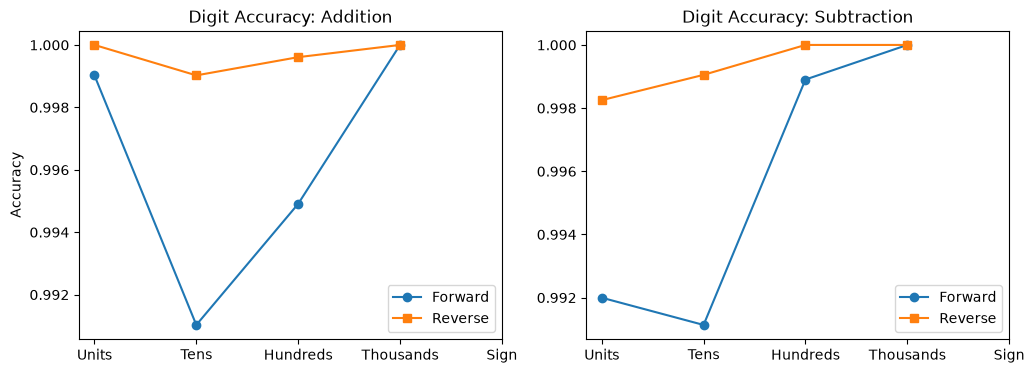

In [32]:
fw_add_res = [r for r in res_fw if r["op"] == "+"]
fw_sub_res = [r for r in res_fw if r["op"] == "-"]
rev_add_res = [r for r in res_rev if r["op"] == "+"]
rev_sub_res = [r for r in res_rev if r["op"] == "-"]

fw_add_dig = compute_digit_accuracy(fw_add_res)
rev_add_dig = compute_digit_accuracy(rev_add_res, is_reverse=True)
fw_sub_dig = compute_digit_accuracy(fw_sub_res)
rev_sub_dig = compute_digit_accuracy(rev_sub_res, is_reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_pos = [0, 1, 2, 3, 4]
x_labels = ["Units", "Tens", "Hundreds", "Thousands", "Sign"]

axes[0].plot(range(len(fw_add_dig)), fw_add_dig, marker='o', label="Forward")
axes[0].plot(range(len(rev_add_dig)), rev_add_dig, marker='s', label="Reverse")
axes[0].set_title("Digit Accuracy: Addition")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(range(len(fw_sub_dig)), fw_sub_dig, marker='o', label="Forward")
axes[1].plot(range(len(rev_sub_dig)), rev_sub_dig, marker='s', label="Reverse")
axes[1].set_title("Digit Accuracy: Subtraction")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels)
axes[1].legend()

plt.savefig('plot/digit_accuracy.png')
plt.show()

## Specific Error Patterns

To understand the algorithms these models are learning, we analyze specific edge cases:

- **Crossing Zero:** Subtractions that result in a negative number.

- **Asymmetric Lengths:** Operations where the operands have different string lengths, disturbing standard positional alignment.

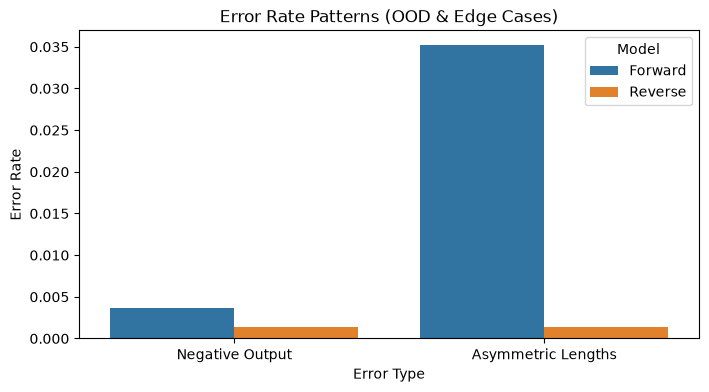

In [33]:
# Let's filter only the errors from both models
errors_fw = [r for r in res_fw if not r["correct"]]
errors_rev = [r for r in res_rev if not r["correct"]]

# Analysis 1: Crossing Zero (Negative Outputs)
fw_neg_total = sum([1 for r in res_fw if r["crossing_zero"]])
fw_neg_errors = sum([1 for r in errors_fw if r["crossing_zero"]])

rev_neg_total = sum([1 for r in res_rev if r["crossing_zero"]])
rev_neg_errors = sum([1 for r in errors_rev if r["crossing_zero"]])

fw_neg_error_rate = fw_neg_errors / max(1, fw_neg_total)
rev_neg_error_rate = rev_neg_errors / max(1, rev_neg_total)

# Analysis 2: Asymmetric Operand Lengths
fw_asym_total = sum([1 for r in res_fw if r["asymmetric"]])
fw_asym_errors = sum([1 for r in errors_fw if r["asymmetric"]])

rev_asym_total = sum([1 for r in res_rev if r["asymmetric"]])
rev_asym_errors = sum([1 for r in errors_rev if r["asymmetric"]])

fw_asym_error_rate = fw_asym_errors / max(1, fw_asym_total)
rev_asym_error_rate = rev_asym_errors / max(1, rev_asym_total)

# Prepare DataFrame for easy plotting
data = {
    "Model": ["Forward", "Forward", "Reverse", "Reverse"],
    "Error Type": ["Negative Output", "Asymmetric Lengths", "Negative Output", "Asymmetric Lengths"],
    "Error Rate": [fw_neg_error_rate, fw_asym_error_rate, rev_neg_error_rate, rev_asym_error_rate]
}
df_errors = pd.DataFrame(data)

plt.figure(figsize=(8, 4))
sns.barplot(x="Error Type", y="Error Rate", hue="Model", data=df_errors)
plt.title("Error Rate Patterns (OOD & Edge Cases)")
plt.ylabel("Error Rate")
plt.savefig('plot/error_rates.png')
plt.show()

### Error Case Examples

Below is a sample of specific failure cases to see exactly where the models stumbled.

In [34]:
fw_error_samples = pd.DataFrame(errors_fw).head(10)
rev_error_samples = pd.DataFrame(errors_rev).head(10)

print("Forward Model - Sample Errors:")
display(fw_error_samples[["prompt", "true_ans", "pred_ans", "op", "crossing_zero", "asymmetric"]])
print("\nReverse Model - Sample Errors:")
display(rev_error_samples[["prompt", "true_ans", "pred_ans", "op", "crossing_zero", "asymmetric"]])

Forward Model - Sample Errors:


,prompt,true_ans,pred_ans,op,crossing_zero,asymmetric
0,450-359=,91,191,-,False,False
1,610-7=,603,643,-,False,True
2,183+1=,184,144,+,False,True
3,984-978=,6,5,-,False,False
4,514-523=,-9,-8,-,True,False
5,304-5=,299,389,-,False,True
6,282-273=,9,10,-,False,False
7,532-524=,8,7,-,False,False
8,679-3=,676,664,-,False,True
9,718-3=,715,716,-,False,True



Reverse Model - Sample Errors:


,prompt,true_ans,pred_ans,op,crossing_zero,asymmetric
0,949-945=,4,-6b19b1,-,False,False
1,311+649=,0c169,0c159,+,False,False
2,33-4=,9b12,-1,-,False,True
3,310-315=,-5,5b19b1,-,True,False
4,13-20=,-7b1,3,-,True,False
5,778-776=,2,-8b1,-,False,False
6,626-627=,-1,9b19b1,-,True,False
7,575-570=,5,-5b1,-,False,False
8,617-618=,-1,9b19b1,-,True,False
9,206-208=,-2,8b1-2,-,True,False


### Error Scatter Plot (Target vs Predicted)

By plotting the predicted numerical answers against the expected mathematical answers, we can see if the models are outputting complete hallucinations (scattered randomly) or making minor errors (clustered near the $y=x$ line).

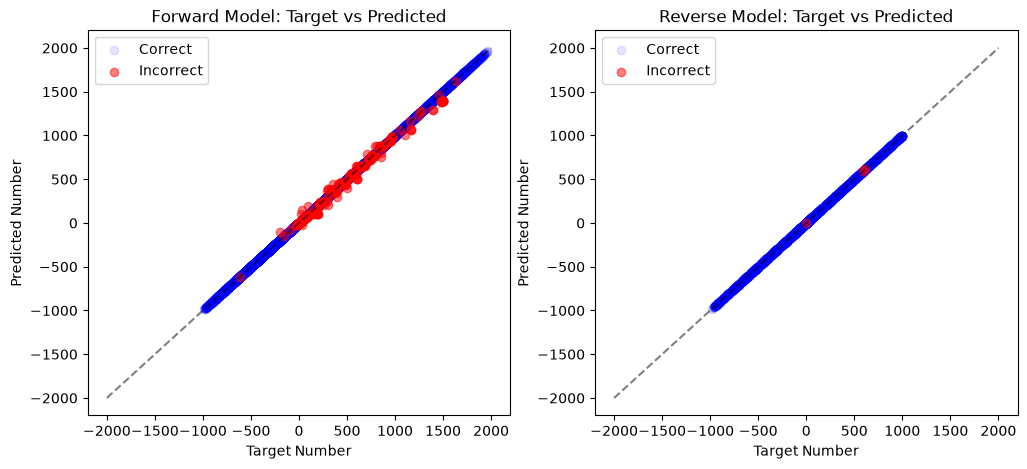

In [35]:
def get_xy(results):
    x_correct, y_correct = [], []
    x_incorrect, y_incorrect = [], []
    for r in results:
        try:
            t = int(r["true_ans"])
            p = int(r["pred_ans"])
            if r["correct"]:
                x_correct.append(t)
                y_correct.append(p)
            else:
                x_incorrect.append(t)
                y_incorrect.append(p)
        except ValueError:
            pass
    return x_correct, y_correct, x_incorrect, y_incorrect

fw_xc, fw_yc, fw_xi, fw_yi = get_xy(res_fw)
rev_xc, rev_yc, rev_xi, rev_yi = get_xy(res_rev)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(fw_xc, fw_yc, color='blue', alpha=0.1, label='Correct')
axes[0].scatter(fw_xi, fw_yi, color='red', alpha=0.5, label='Incorrect')
axes[0].plot([-2000, 2000], [-2000, 2000], 'k--', alpha=0.5)
axes[0].set_title('Forward Model: Target vs Predicted')
axes[0].set_xlabel('Target Number')
axes[0].set_ylabel('Predicted Number')
axes[0].legend()

axes[1].scatter(rev_xc, rev_yc, color='blue', alpha=0.1, label='Correct')
axes[1].scatter(rev_xi, rev_yi, color='red', alpha=0.5, label='Incorrect')
axes[1].plot([-2000, 2000], [-2000, 2000], 'k--', alpha=0.5)
axes[1].set_title('Reverse Model: Target vs Predicted')
axes[1].set_xlabel('Target Number')
axes[1].set_ylabel('Predicted Number')
axes[1].legend()

plt.savefig('plot/target_vs_predicted.png')
plt.show()

## Length Generalization (Out-of-Distribution)

Does the LLM actually learn the general mathematical algorithm, or just memorize 3-digit length patterns? We test the model on 4-digit and 5-digit arithmetic which it has never seen during training.

In [36]:
# Generate some Out-of-Distribution 4-digit and 5-digit sums
ood_prompts = [
    ("1000+2000=", "3000"),
    ("9999+1=", "10000"),
    ("12345+54321=", "66666"),
    ("5000-1000=", "4000"),
    ("9999-9999=", "0"),
    ("1111+2222=", "3333"),
    ("8888-4444=", "4444"),
    ("10000+20000=", "30000"),
    ("7777+3333=", "11110"),
    ("50000-1=", "49999")
]

print("Out of Distribution (Length Generalization) Testing:\n")
print(f"{'Prompt':<15} | {'Expected':<15} | {'Forward Pred':<15} | {'Reverse Pred':<15}")
print("-" * 68)

for p, true_ans in ood_prompts:
    padded_prompts = [[tokenizer.token_to_id['[PAD]']] * (15 - len(p)) + tokenizer.encode(p)]
    X = torch.tensor(padded_prompts, dtype=torch.long).transpose(0, 1).to(device)
    
    # Forward Model
    input_tensor_fw = X
    for _ in range(15):
        output, _, _ = model_fw(input_tensor_fw)
        token = torch.argmax(output[-1, :, :], -1).view(1, -1)
        input_tensor_fw = torch.cat((input_tensor_fw, token), 0)
        
    pred_tokens_fw = input_tensor_fw[15:, 0].tolist()
    if tokenizer.token_to_id['[EOS]'] in pred_tokens_fw:
        pred_tokens_fw = pred_tokens_fw[:pred_tokens_fw.index(tokenizer.token_to_id['[EOS]'])]
    pred_str_fw = tokenizer.decode(pred_tokens_fw)
    
    # Reverse Model
    input_tensor_rev = X
    for _ in range(15):
        output, _, _ = model_rev(input_tensor_rev)
        token = torch.argmax(output[-1, :, :], -1).view(1, -1)
        input_tensor_rev = torch.cat((input_tensor_rev, token), 0)
        
    pred_tokens_rev = input_tensor_rev[15:, 0].tolist()
    if tokenizer.token_to_id['[EOS]'] in pred_tokens_rev:
        pred_tokens_rev = pred_tokens_rev[:pred_tokens_rev.index(tokenizer.token_to_id['[EOS]'])]
    pred_str_rev = tokenizer.decode(pred_tokens_rev).replace("c1", "").replace("b1", "").replace("c", "").replace("b", "")[::-1]
    
    print(f"{p:<15} | {true_ans:<15} | {pred_str_fw:<15} | {pred_str_rev:<15}")

Out of Distribution (Length Generalization) Testing:

Prompt          | Expected        | Forward Pred    | Reverse Pred   
--------------------------------------------------------------------
1000+2000=      | 3000            | -1              | 10             
9999+1=         | 10000           | 111111119-9-9-9 | 8              
12345+54321=    | 66666           | -               | 28             
5000-1000=      | 4000            |                 | 0              
9999-9999=      | 0               | -900            | 0-             
1111+2222=      | 3333            |                 | 13             
8888-4444=      | 4444            |                 | 0-             
10000+20000=    | 30000           |                 | 01             
7777+3333=      | 11110           | 7               | 3              
50000-1=        | 49999           | -11             | 0              
